/var/folders/cl/5tmd8kpj5lgb577xbcs0r2tw0000gn/T/ipykernel_1314/3711088339.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data_to_plot, labels=neighborhoods, patch_artist=True,


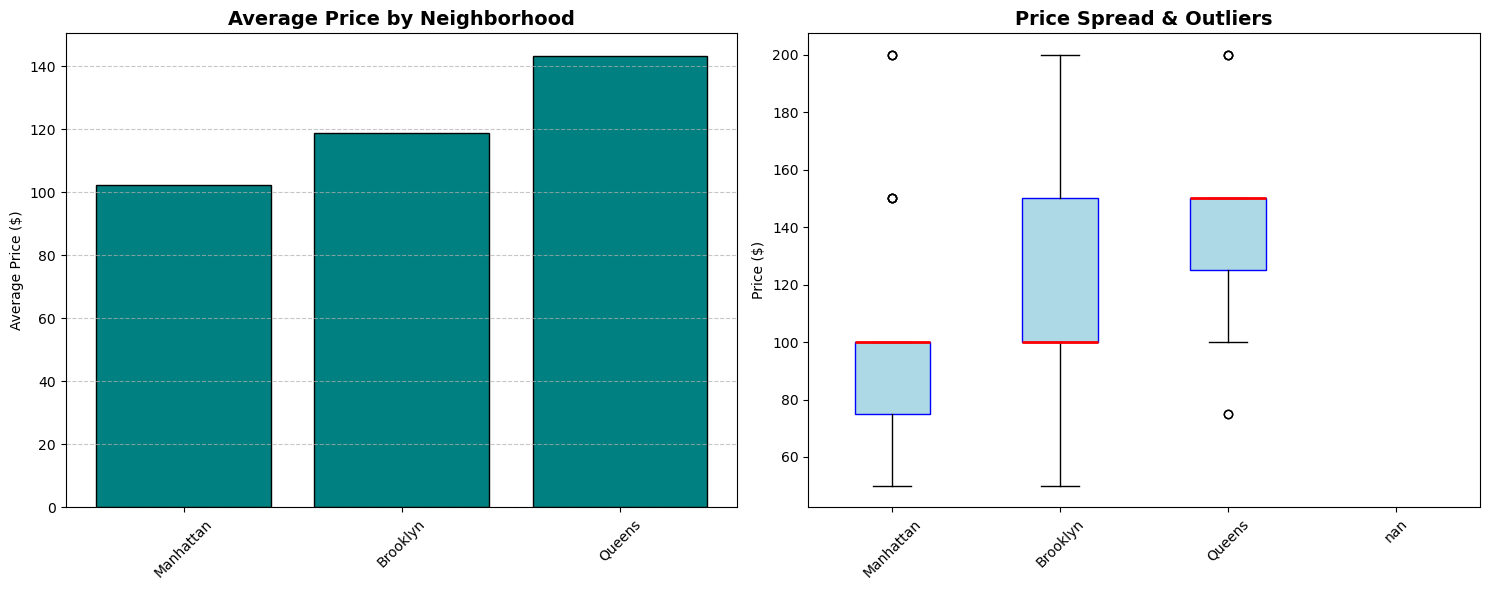

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. LOAD DATA
df = pd.read_csv('unclean_airbnb_data.csv', encoding='utf-8-sig')
df.columns = df.columns.str.strip()

# 2. CLEANING & STANDARDIZATION
text_cols = ['host_name', 'neighbourhood', 'room_type']
for col in text_cols:
    df[col] = df[col].str.strip().str.title()

df['neighbourhood'] = df['neighbourhood'].replace({'Manhatan': 'Manhattan'})

# 3. SMART IMPUTATION
df['price'] = df['price'].fillna(df.groupby('neighbourhood')['price'].transform('median'))
df['room_type'] = df['room_type'].fillna('Unknown')

# 4. TYPE CONVERSION
cols_to_int = ['minimum_nights', 'number_of_reviews', 'availability_365']
for col in cols_to_int:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# 5. VISUALIZATION
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Average Price by Neighborhood (Bar Chart)
avg_prices = df.groupby('neighbourhood')['price'].mean().sort_values()
ax1.bar(avg_prices.index, avg_prices.values, color='teal', edgecolor='black')
ax1.set_title('Average Price by Neighborhood', fontsize=14, fontweight='bold')
ax1.set_ylabel('Average Price ($)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 2: Price Distribution (Box Plot)
# We need to create a list of data arrays for each neighborhood
neighborhoods = df['neighbourhood'].unique()
data_to_plot = [df[df['neighbourhood'] == n]['price'].dropna() for n in neighborhoods]

ax2.boxplot(data_to_plot, labels=neighborhoods, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red', linewidth=2))
ax2.set_title('Price Spread & Outliers', fontsize=14, fontweight='bold')
ax2.set_ylabel('Price ($)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()